<a href="https://colab.research.google.com/github/MohtadiIbtesum/cse422_project/blob/main/gender.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Employee Gender Prediction
### Supervised Learning & Exploratory Data Analysis

**How to run:** In Google Colab, go to `Runtime > Run all`. The first code cell will prompt you to upload your CSV file.


In [18]:
# Run this cell and select your dataset when prompted
from google.colab import files
uploaded = files.upload()

Saving 4.csv to 4 (1).csv


In [19]:
# Core data handling
import pandas as pd
import numpy as np

# Plotting
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing & splitting
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.decomposition import PCA
from imblearn.over_sampling import SMOTE

# Supervised models
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

# Neural network
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import BinaryCrossentropy

# Metrics
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, ConfusionMatrixDisplay,
                              roc_auc_score, roc_curve)

sns.set_style('whitegrid')
np.random.seed(42)
tf.random.set_seed(42)

# Folder setup for results
import os
OUTPUT_DIR = 'results'
os.makedirs(OUTPUT_DIR, exist_ok=True)
saved_files = []

def save_fig(fig, name):
    path = os.path.join(OUTPUT_DIR, name)
    fig.savefig(path, bbox_inches='tight', dpi=300)
    saved_files.append(path)
    return path

def save_table(df, name):
    path = os.path.join(OUTPUT_DIR, name)
    df.to_csv(path)
    saved_files.append(path)
    return path


In [20]:
# Load Data & Basic Info
file_name = list(uploaded.keys())[0] if 'uploaded' in locals() else '4.csv'
df = pd.read_csv(file_name)
print("Shape (rows, columns):", df.shape)

print("\nFeature dtypes:")
print(df.dtypes.value_counts())

print("\nCategorical columns:")
print(df.select_dtypes(include='object').columns.tolist())

display(df.head())


Shape (rows, columns): (1509, 35)

Feature dtypes:
int64     27
object     8
Name: count, dtype: int64

Categorical columns:
['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'Over18', 'OverTime']


,id,Age,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Attrition
0,0,36,Travel_Frequently,599,Research & Development,24,3,Medical,1,4,Male,42,3,1,Laboratory Technician,4,Married,2596,5099,1,Y,Yes,13,3,2,80,1,10,2,3,10,0,7,8,0
1,1448,33,Travel_Rarely,530,Sales,3,3,Marketing,1,3,Male,46,3,3,Sales Executive,3,Single,10903,8040,1,Y,Yes,13,3,1,80,0,13,5,3,11,9,6,6,0
2,259,41,Travel_Rarely,1146,Sales,2,3,Medical,1,4,Female,56,3,2,Sales Executive,4,Single,9852,23099,1,Y,No,12,3,4,80,0,10,2,3,10,8,6,0,0
3,340,40,Travel_Rarely,1499,Sales,26,3,Marketing,1,1,Male,76,3,4,Sales Executive,3,Single,13402,11652,4,Y,Yes,20,4,2,80,0,22,3,2,19,7,3,7,0
4,1098,35,Travel_Frequently,806,Research & Development,2,4,Life Sciences,1,4,Female,77,4,1,Research Scientist,2,Married,2996,19121,1,Y,Yes,12,3,4,80,0,6,2,2,6,0,1,3,0


Gender
Male      950
Female    559
Name: count, dtype: int64


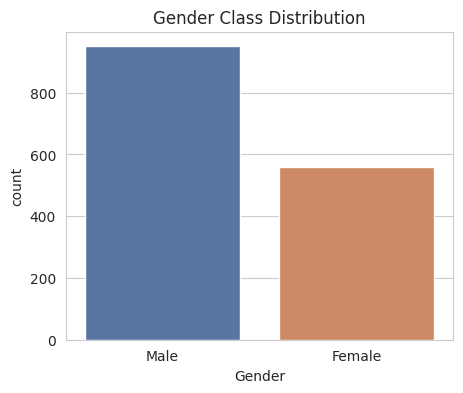

Gender Distribution: 63.0% Male, 37.0% Female


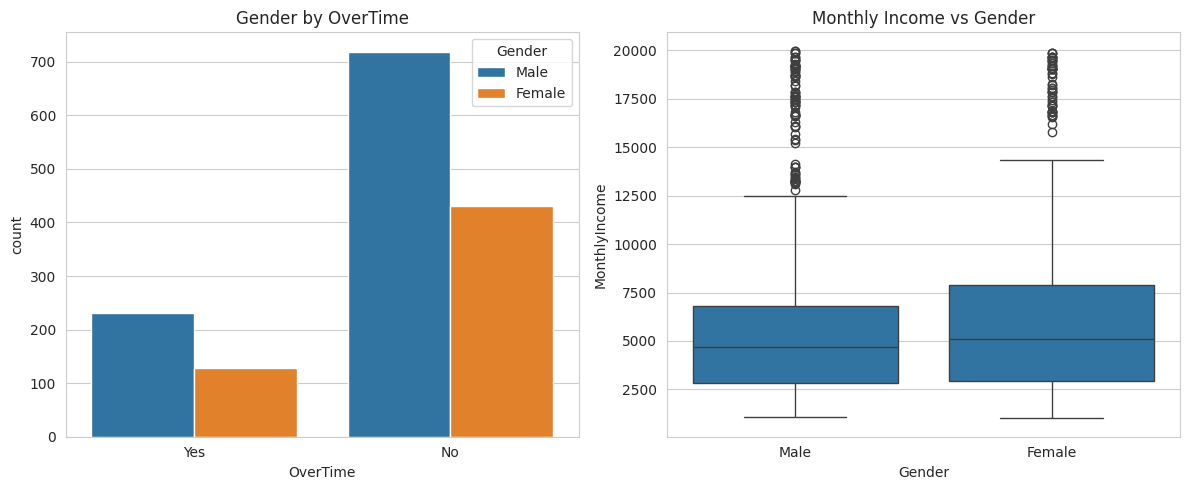

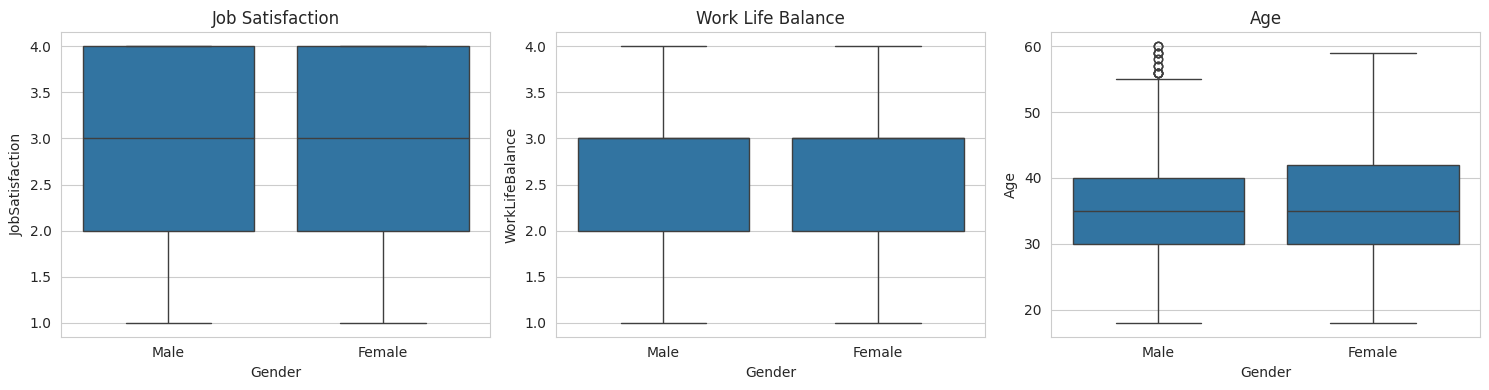


Proportion of Male Employees by Department:
Department
Human Resources           0.685714
Research & Development    0.632479
Sales                     0.617577
Name: Gender_Num, dtype: float64


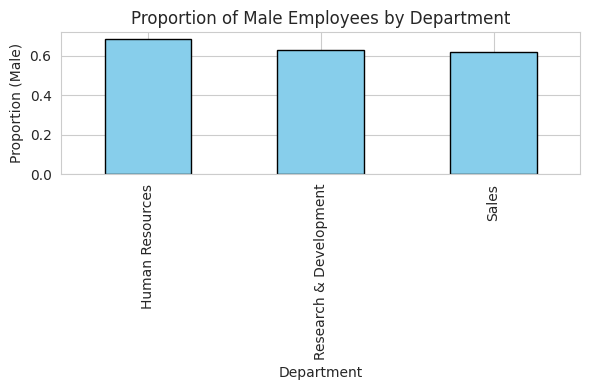

In [21]:
# 1. Gender Class Distribution
attr_counts = df['Gender'].value_counts()
print(attr_counts)

fig = plt.figure(figsize=(5,4))
sns.countplot(x='Gender', data=df, hue='Gender', palette=['#4C72B0', '#DD8452'], legend=False)
plt.title('Gender Class Distribution')
save_fig(fig, '01_Gender_class_distribution.png')
plt.show()

print(f"Gender Distribution: {attr_counts.get('Male', 0) / len(df) * 100:.1f}% Male, {attr_counts.get('Female', 0) / len(df) * 100:.1f}% Female")

# 2. Bivariate EDA
fig, axes = plt.subplots(1, 2, figsize=(12,5))
sns.countplot(x='OverTime', hue='Gender', data=df, ax=axes[0])
axes[0].set_title('Gender by OverTime')
sns.boxplot(x='Gender', y='MonthlyIncome', data=df, ax=axes[1])
axes[1].set_title('Monthly Income vs Gender')
plt.tight_layout()
save_fig(fig, '02_overtime_and_income_vs_Gender.png')
plt.show()

# 3. Satisfaction, WorkLifeBalance, and Age vs Gender
fig, axes = plt.subplots(1, 3, figsize=(15,4))
sns.boxplot(x='Gender', y='JobSatisfaction', data=df, ax=axes[0])
sns.boxplot(x='Gender', y='WorkLifeBalance', data=df, ax=axes[1])
sns.boxplot(x='Gender', y='Age', data=df, ax=axes[2])
axes[0].set_title('Job Satisfaction')
axes[1].set_title('Work Life Balance')
axes[2].set_title('Age')
plt.tight_layout()
save_fig(fig, '03_satisfaction_worklife_age_vs_Gender.png')
plt.show()

# 4. Proportion of Male Employees by Department
attr_by_dept = df.assign(Gender_Num=(df['Gender'] == 'Male').astype(int)).groupby('Department')['Gender_Num'].mean().sort_values(ascending=False)

print("\nProportion of Male Employees by Department:")
print(attr_by_dept)

fig = plt.figure(figsize=(6,4))
attr_by_dept.plot(kind='bar', title='Proportion of Male Employees by Department', color='skyblue', edgecolor='black')
plt.ylabel('Proportion (Male)')
plt.tight_layout()
save_fig(fig, '05_Gender_rate_by_department.png')
plt.show()


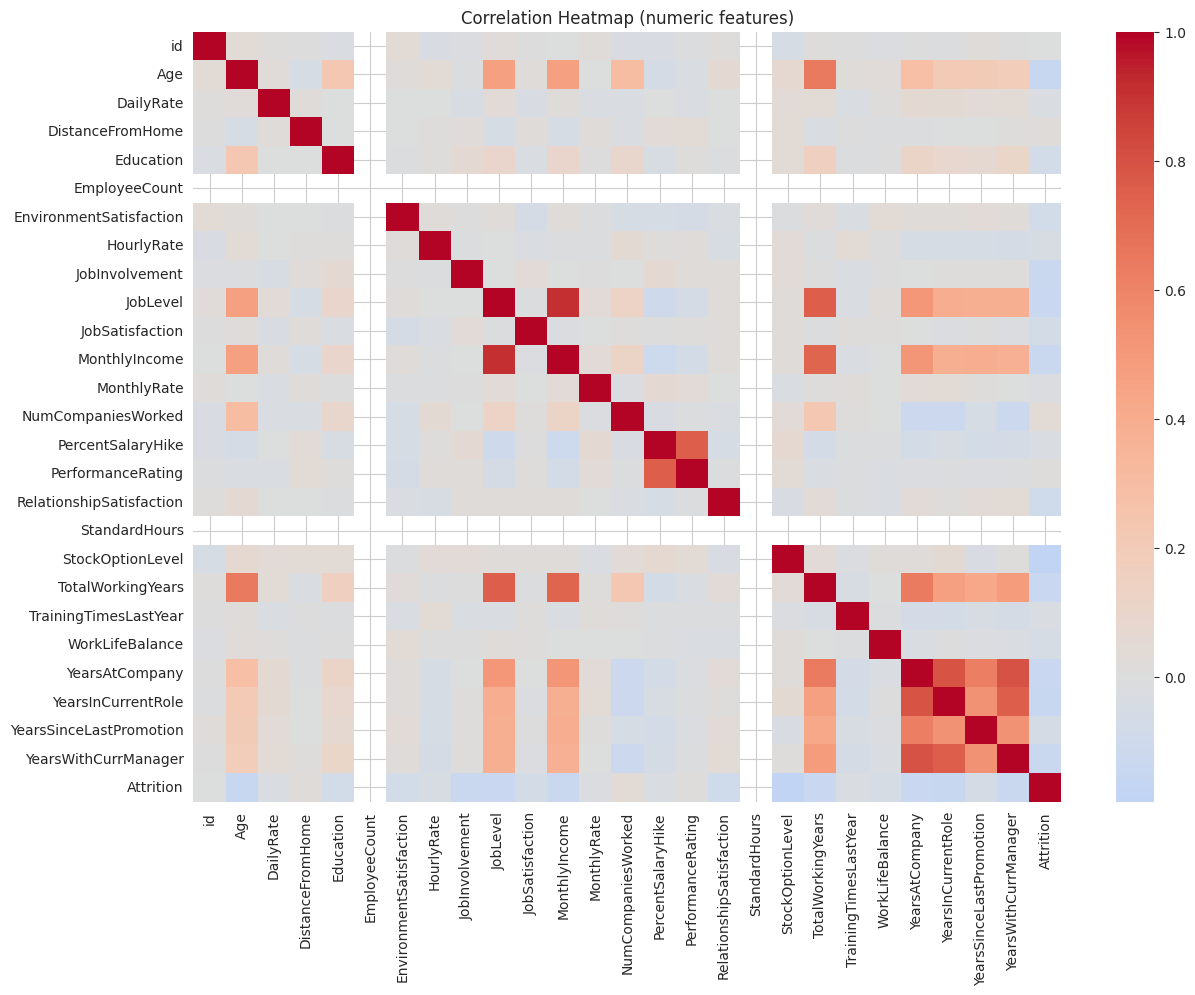

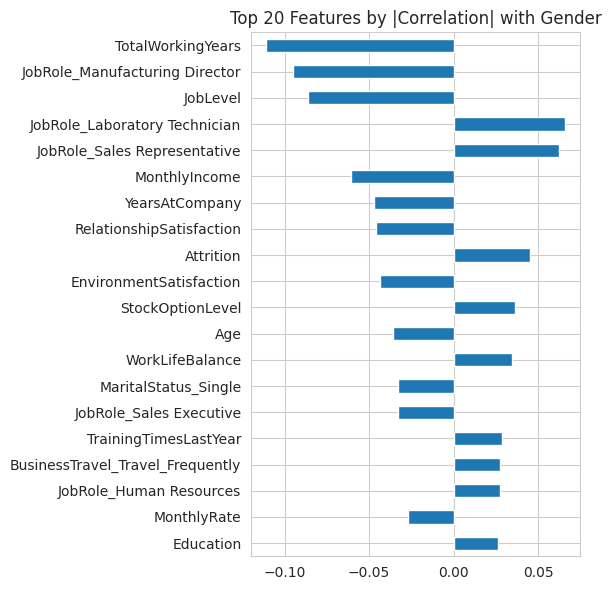

In [22]:
# Drop uninformative columns
drop_cols = ['EmployeeCount', 'Over18', 'StandardHours', 'id']
df_clean = df.drop(columns=[c for c in drop_cols if c in df.columns])

# Handle Nulls and Duplicates
df_clean = df_clean.dropna().drop_duplicates()

# Target and Categorical variable definition
target_col = 'Gender'
cat_cols = df_clean.select_dtypes(include='object').columns.tolist()

# Label Encode the Target Variable ('Female' = 0, 'Male' = 1)
if target_col in cat_cols:
    cat_cols.remove(target_col)
    le = LabelEncoder()
    df_clean[target_col] = le.fit_transform(df_clean[target_col])

# One-Hot Encode remaining categorical features
df_clean = pd.get_dummies(df_clean, columns=cat_cols, drop_first=True)

# Define X and y
X = df_clean.drop(columns=[target_col])
y = df_clean[target_col]

# Correlation Heatmap
fig = plt.figure(figsize=(14,10))
numeric_df = df.select_dtypes(include=np.number)
sns.heatmap(numeric_df.corr(), cmap='coolwarm', center=0, annot=False)
plt.title('Correlation Heatmap (numeric features)')
save_fig(fig, '04_correlation_heatmap.png')
plt.show()

# Top Correlated Features with Gender
corr_with_target = df_clean.corr()[target_col].drop(target_col).sort_values(key=abs, ascending=False)
fig = plt.figure(figsize=(6,6))
corr_with_target.head(20).plot(kind='barh')
plt.title('Top 20 Features by |Correlation| with Gender')
plt.gca().invert_yaxis()
plt.tight_layout()
save_fig(fig, '06_top_correlated_features.png')
plt.show()

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Scaling
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# SMOTE for Class Imbalance
smote = SMOTE(random_state=42)
X_train_scaled, y_train = smote.fit_resample(X_train_scaled, y_train)

# PCA
pca_fs = PCA(random_state=42)
pca_fs.fit(X_train_scaled)
cum_var = np.cumsum(pca_fs.explained_variance_ratio_)
n_components_90 = np.argmax(cum_var >= 0.90) + 1
pca_final = PCA(n_components=n_components_90, random_state=42)
X_train_pca = pca_final.fit_transform(X_train_scaled)
X_test_pca = pca_final.transform(X_test_scaled)


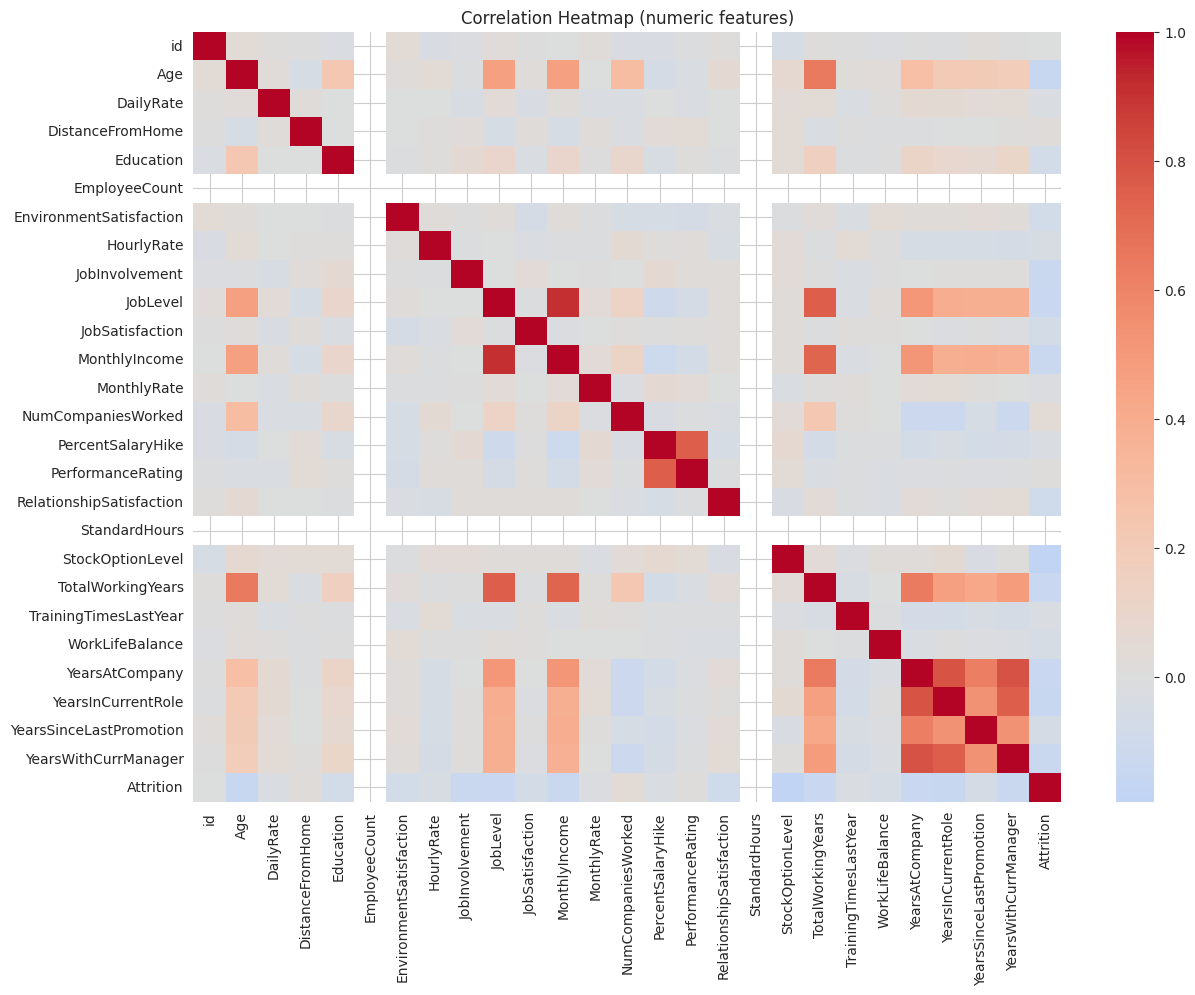

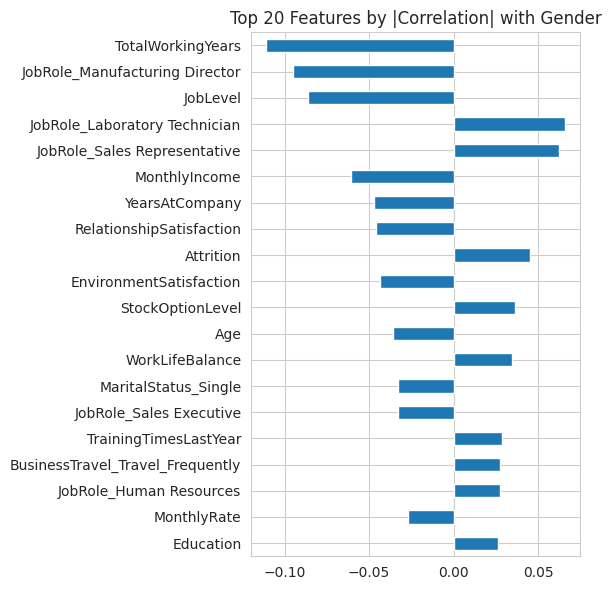

In [23]:
# Drop uninformative columns
drop_cols = ['EmployeeCount', 'Over18', 'StandardHours', 'id']
df_clean = df.drop(columns=[c for c in drop_cols if c in df.columns])

# Handle Nulls and Duplicates
df_clean = df_clean.dropna().drop_duplicates()

# Target and Categorical variable definition
target_col = 'Gender'
cat_cols = df_clean.select_dtypes(include='object').columns.tolist()

# Label Encode the Target Variable ('Female' = 0, 'Male' = 1)
if target_col in cat_cols:
    cat_cols.remove(target_col)
    le = LabelEncoder()
    df_clean[target_col] = le.fit_transform(df_clean[target_col])

# One-Hot Encode remaining categorical features
df_clean = pd.get_dummies(df_clean, columns=cat_cols, drop_first=True)

# Define X and y
X = df_clean.drop(columns=[target_col])
y = df_clean[target_col]

# Correlation Heatmap
fig = plt.figure(figsize=(14,10))
numeric_df = df.select_dtypes(include=np.number)
sns.heatmap(numeric_df.corr(), cmap='coolwarm', center=0, annot=False)
plt.title('Correlation Heatmap (numeric features)')
save_fig(fig, '04_correlation_heatmap.png')
plt.show()

# Top Correlated Features with Gender
corr_with_target = df_clean.corr()[target_col].drop(target_col).sort_values(key=abs, ascending=False)
fig = plt.figure(figsize=(6,6))
corr_with_target.head(20).plot(kind='barh')
plt.title('Top 20 Features by |Correlation| with Gender')
plt.gca().invert_yaxis()
plt.tight_layout()
save_fig(fig, '06_top_correlated_features.png')
plt.show()

# --- THE NEW 6-PART SPLIT ---
# Break off exactly 1/6th of the data for the dedicated Test Set
X_train_cv, X_test, y_train_cv, y_test = train_test_split(
    X, y,
    test_size=1/6,
    random_state=42,
    stratify=y
)

# Scaling
scaler = MinMaxScaler()
X_train_cv_scaled = scaler.fit_transform(X_train_cv)
X_test_scaled = scaler.transform(X_test)

# SMOTE for Class Imbalance (applied ONLY to the 5/6th training data)
smote = SMOTE(random_state=42)
X_train_cv_scaled, y_train_cv = smote.fit_resample(X_train_cv_scaled, y_train_cv)

# PCA (fit ONLY on the 5/6th training data)
pca_fs = PCA(random_state=42)
pca_fs.fit(X_train_cv_scaled)
cum_var = np.cumsum(pca_fs.explained_variance_ratio_)
n_components_90 = np.argmax(cum_var >= 0.90) + 1
pca_final = PCA(n_components=n_components_90, random_state=42)
X_train_pca = pca_final.fit_transform(X_train_cv_scaled)
X_test_pca = pca_final.transform(X_test_scaled)

In [24]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    'Naive Bayes': GaussianNB(),
    'Random Forest': RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
}

trained = {}
predictions = {}
probabilities = {}

# Train Scikit-Learn Models
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    trained[name] = model
    probs = model.predict_proba(X_test_scaled)[:, 1]
    probabilities[name] = probs
    predictions[name] = model.predict(X_test_scaled)
    print(f"{name} trained.")

# Neural Network Setup
n_features = X_train_scaled.shape[1]
class_weight_dict = {
    0: 1.0,
    1: (y_train == 0).sum() / (y_train == 1).sum()
}

nn_model = Sequential([
    Dense(32, activation='relu', input_shape=(n_features,)),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

nn_model.compile(optimizer=Adam(learning_rate=0.001), loss=BinaryCrossentropy(), metrics=['accuracy'])
nn_history = nn_model.fit(X_train_scaled, y_train, validation_split=0.15, epochs=60, batch_size=32, class_weight=class_weight_dict, verbose=0)

nn_proba = nn_model.predict(X_test_scaled, verbose=0).ravel()
nn_pred = (nn_proba >= 0.5).astype(int)

trained['Neural Network'] = nn_model
predictions['Neural Network'] = nn_pred
probabilities['Neural Network'] = nn_proba
models['Neural Network'] = nn_model

print("Neural Network trained.")


Logistic Regression trained.
Naive Bayes trained.
Random Forest trained.


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Neural Network trained.


,Accuracy,Precision,Recall,F1 Score,AUC
Logistic Regression,0.571,0.671,0.629,0.649,0.541
Naive Bayes,0.536,0.667,0.528,0.589,0.532
Random Forest,0.595,0.640,0.818,0.718,0.523
Neural Network,0.631,0.660,0.855,0.745,0.541


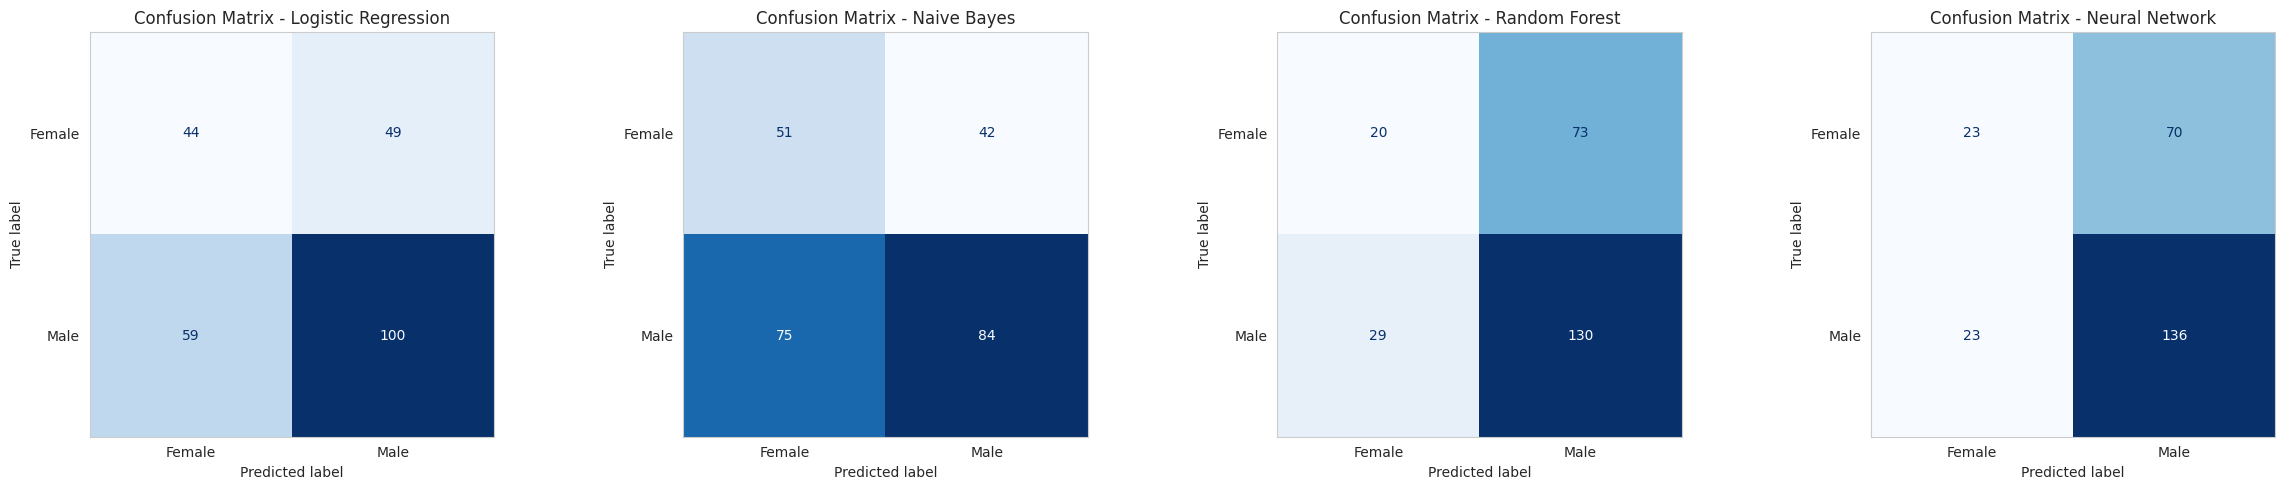

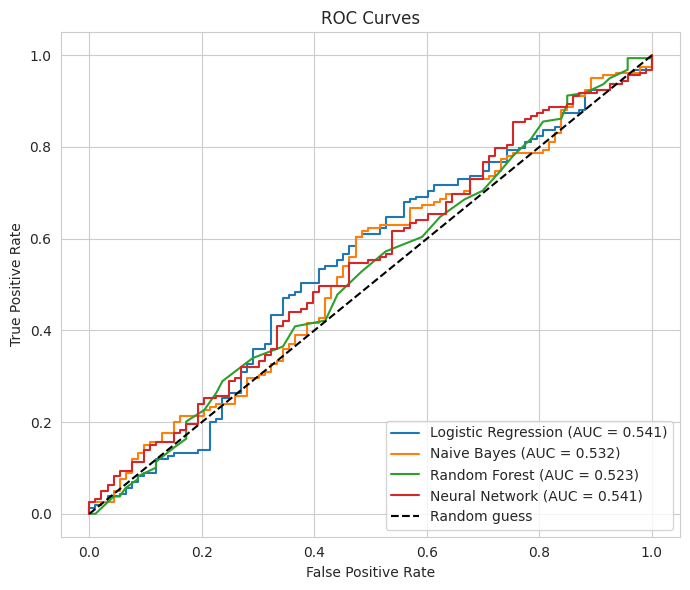

In [25]:
eval_results = {}

for name in models:
    y_pred = predictions[name]
    y_proba = probabilities[name]
    eval_results[name] = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1 Score': f1_score(y_test, y_pred),
        'AUC': roc_auc_score(y_test, y_proba)
    }

results_df = pd.DataFrame(eval_results).T
display(results_df.round(3))
save_table(results_df, 'model_comparison_results.csv')

# Plot Confusion Matrices (Labels: Female=0, Male=1)
fig, axes = plt.subplots(1, len(models), figsize=(6*len(models), 5))
for ax, name in zip(axes, models):
    cm = confusion_matrix(y_test, predictions[name])
    ConfusionMatrixDisplay(cm, display_labels=['Female', 'Male']).plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'Confusion Matrix - {name}')
    ax.grid(False)
plt.tight_layout()
save_fig(fig, '11_confusion_matrices.png')
plt.show()

# ROC Curves
fig = plt.figure(figsize=(7,6))
for name in models:
    fpr, tpr, _ = roc_curve(y_test, probabilities[name])
    auc = eval_results[name]['AUC']
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})')

plt.plot([0,1], [0,1], 'k--', label='Random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves')
plt.legend(loc='lower right')
plt.tight_layout()
save_fig(fig, '13_roc_curves.png')
plt.show()


In [26]:
import pandas as pd
import numpy as np

# 1. Load the real test dataset
test_readable = pd.read_csv('4_test.csv')

# Drop the uninformative columns just like we did for the training data
drop_cols = ['EmployeeCount', 'Over18', 'StandardHours', 'id']
test_clean = test_readable.drop(columns=[c for c in drop_cols if c in test_readable.columns])

# If your test set already includes the 'Gender' column, drop it from the features
if 'Gender' in test_clean.columns:
    test_clean = test_clean.drop(columns=['Gender'])

# 2. One-Hot Encode the test data just like we did for the training data
cat_cols_test = test_clean.select_dtypes(include='object').columns.tolist()
test_encoded = pd.get_dummies(test_clean, columns=cat_cols_test, drop_first=True)

# 3. ALIGNMENT (Crucial Step):
# The test set might be missing some categories that existed in the training set.
# This forces the test dataframe to have the exact same columns in the exact same order as training (X.columns).
# Any missing one-hot columns are automatically added and filled with 0 (False).
test_encoded = test_encoded.reindex(columns=X.columns, fill_value=0)

# 4. Scale the features using the scaler fitted in Section 4
test_scaled = scaler.transform(test_encoded)

# 5. Generate predictions for each model
pred_table = test_readable.copy()

for name, model in trained.items():
    if name == 'Neural Network':
        probs = model.predict(test_scaled, verbose=0).ravel()
    else:
        probs = model.predict_proba(test_scaled)[:, 1]

    # Check if the model is Random Forest to apply a custom threshold if needed
    if name == 'Random Forest':
        threshold = 0.50  # Update this if your threshold optimization outputted a different number
        preds = (probs >= threshold).astype(int)
    else:
        preds = (probs >= 0.5).astype(int)

    # Map predictions back to text (1 = Male, 0 = Female)
    pred_table[f'{name} Prediction'] = np.where(preds == 1, 'Male', 'Female')
    pred_table[f'{name} P(Male)'] = probs.round(3)

pd.set_option('display.max_columns', None)
save_table(pred_table, 'custom_test_gender_predictions.csv')
display(pred_table)

,id,Age,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Attrition,Logistic Regression Prediction,Logistic Regression P(Male),Naive Bayes Prediction,Naive Bayes P(Male),Random Forest Prediction,Random Forest P(Male),Neural Network Prediction,Neural Network P(Male)
0,1309,31,Travel_Rarely,1448,Research & Development,3,3,Medical,1,3,Male,81,2,1,Laboratory Technician,3,Single,3875,21086,7,Y,No,11,3,2,80,0,4,6,3,3,2,1,2,1,Male,0.700,Male,0.977,Male,0.75,Male,0.612
1,1081,35,Travel_Rarely,885,Research & Development,1,2,Medical,1,2,Male,70,3,1,Laboratory Technician,1,Married,2886,18256,1,Y,No,11,3,2,80,0,5,2,4,5,3,1,3,0,Male,0.665,Male,0.712,Male,0.68,Male,0.764
2,1583,44,Travel_Rarely,836,Research & Development,29,5,Life Sciences,1,3,Male,100,3,2,Laboratory Technician,4,Married,6272,4605,8,Y,No,18,3,3,80,1,8,3,2,5,4,0,4,0,Male,0.615,Male,0.693,Female,0.49,Male,0.926
3,711,29,Travel_Rarely,1206,Research & Development,7,3,Medical,1,2,Male,89,3,1,Research Scientist,4,Married,2976,11781,1,Y,No,13,3,2,80,0,1,5,3,1,0,0,0,1,Male,0.644,Male,0.897,Male,0.78,Male,0.908
4,1388,36,Travel_Rarely,949,Research & Development,1,4,Life Sciences,1,2,Male,57,2,3,Manufacturing Director,3,Married,10008,12023,1,Y,No,14,3,4,80,1,10,3,3,10,9,1,9,0,Female,0.474,Female,0.020,Male,0.57,Female,0.376
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
163,546,27,Travel_Rarely,482,Sales,2,2,Other,1,2,Male,92,3,2,Sales Executive,4,Married,4249,2690,2,Y,Yes,21,4,1,80,1,5,2,2,3,2,0,2,0,Male,0.546,Male,0.735,Male,0.58,Female,0.385
164,470,33,Travel_Rarely,1245,Research & Development,10,4,Other,1,1,Male,70,4,2,Research Scientist,3,Married,5775,16143,4,Y,No,19,3,2,80,0,10,5,4,7,7,0,2,0,Male,0.608,Male,0.547,Male,0.79,Male,0.959
165,1244,40,Travel_Rarely,895,Research & Development,20,3,Medical,1,3,Male,52,2,2,Healthcare Representative,4,Married,7978,21534,1,Y,No,13,3,4,80,0,10,2,3,10,7,0,4,0,Male,0.584,Female,0.182,Female,0.46,Male,0.628
166,515,25,Travel_Frequently,672,Research & Development,1,3,Medical,1,3,Female,96,2,1,Laboratory Technician,4,Married,3730,25308,1,Y,Yes,21,4,4,80,1,7,3,3,7,3,7,6,0,Male,0.773,Male,0.993,Male,0.67,Male,0.847


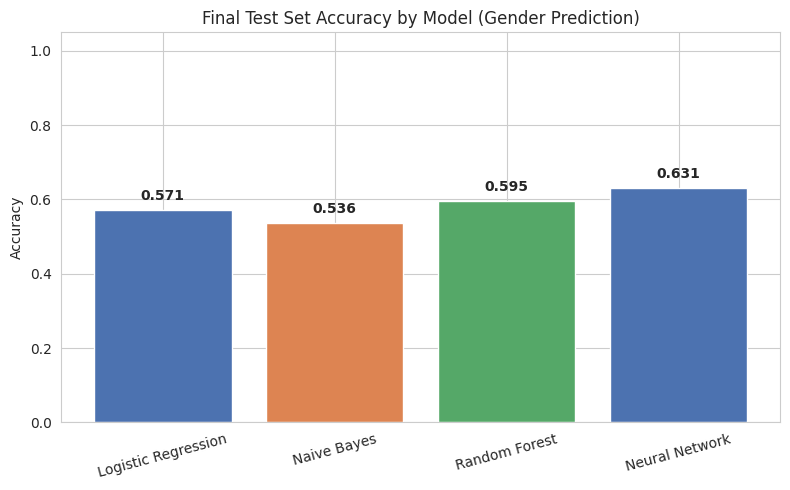

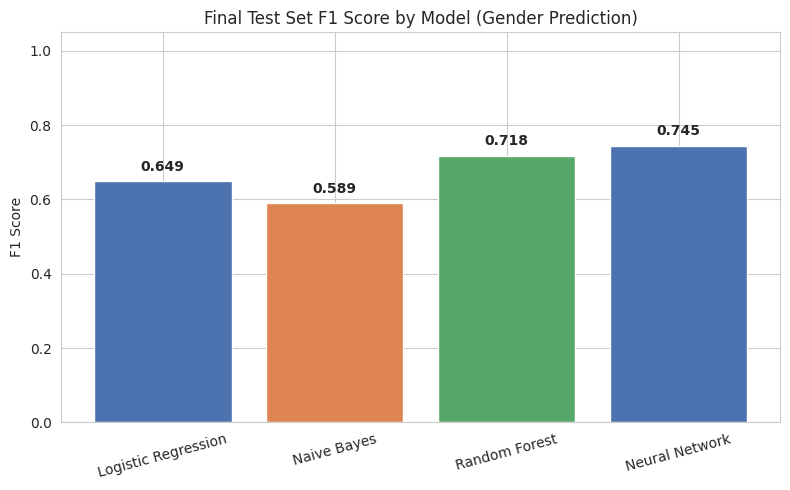

In [27]:
# Create a bar chart specifically for Test Accuracy
fig = plt.figure(figsize=(8, 5))

# Extract just the accuracy column from our results dataframe
accuracies = results_df['Accuracy']
colors = ['#4C72B0', '#DD8452', '#55A868']

# Plot the bars
bars = plt.bar(accuracies.index, accuracies.values, color=colors[:len(accuracies)])

# Add labels and formatting
plt.title('Final Test Set Accuracy by Model (Gender Prediction)')
plt.ylabel('Accuracy')
plt.ylim(0, 1.05)
plt.xticks(rotation=15)

# Add the exact numbers on top of the bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.02,
             f'{yval:.3f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
save_fig(fig, '15_final_accuracy_comparison.png')
plt.show()


# Create a bar chart specifically for Test F1 Scores
fig = plt.figure(figsize=(8, 5))

# Extract the F1 Score column from our results dataframe
f1_scores = results_df['F1 Score']

# Plot the bars
bars = plt.bar(f1_scores.index, f1_scores.values, color=colors[:len(f1_scores)])

# Add labels and formatting
plt.title('Final Test Set F1 Score by Model (Gender Prediction)')
plt.ylabel('F1 Score')
plt.ylim(0, 1.05)
plt.xticks(rotation=15)

# Add the exact numbers on top of the bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.02,
             f'{yval:.3f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
save_fig(fig, '16_final_f1_comparison.png')
plt.show()

In [28]:
import shutil
from google.colab import files

# Compress the 'results' directory into a zip file
zip_filename = 'Gender_Prediction_Results'
shutil.make_archive(zip_filename, 'zip', OUTPUT_DIR)

# Trigger the download to your local machine
files.download(f"{zip_filename}.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>